# Análise de Poder Estatístico (Issue 2.4)

## Motivação

O Capítulo 5 da dissertação avalia modelos em conjuntos de teste com **60–177 amostras** e razão de classes em torno de 60–76 % positivos. A questão levantada na Issue 2.4 é: esses tamanhos de teste são suficientes para detectar diferenças de AUC que teriam relevância prática?

Se o erro padrão (SE) do AUC sob a hipótese nula for grande em relação ao efeito observado, a maioria dos resultados reportados pode simplesmente refletir variação amostral — e não diferenças reais entre modelos.

Esta análise quantifica:
1. **SE do AUC sob H₀** — dispersão esperada de AUC = 0,50 para cada cenário de tamanho/balanceamento.
2. **Efeito Mínimo Detectável (MDE)** — menor Δ AUC que seria detectado com α = 0,05 bilateral e poder = 80 %.
3. **Quais efeitos observados na dissertação são detectáveis** nessas condições.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm

## Funções: SE do AUC e MDE

### Fórmula de Hanley & McNeil (1982)

Sob a hipótese nula (AUC = 0,50, classificador sem poder discriminativo), o erro padrão do AUC é dado por:

$$\text{SE}_{\text{nulo}}(n_1, n_0) = \sqrt{\frac{n_1 + n_0 + 1}{12 \, n_1 \, n_0}}$$

onde $n_1$ é o número de positivos e $n_0$ o de negativos no conjunto de teste.

### Efeito Mínimo Detectável

Para um teste z bilateral com nível de significância $\alpha$ e poder $1-\beta$:

$$\text{MDE} = \text{SE} \times (z_{\alpha/2} + z_\beta)$$

Com α = 0,05 e poder = 80 %, $(z_{0,025} + z_{0,20}) = 1{,}960 + 0{,}842 = 2{,}802$.

In [2]:
def auc_se_null(n1: int, n0: int) -> float:
    """SE do AUC sob H0 (AUC = 0.5) via Hanley & McNeil (1982).
    
    Parameters
    ----------
    n1 : int
        Número de positivos no conjunto de teste.
    n0 : int
        Número de negativos no conjunto de teste.

    Returns
    -------
    float
        Erro padrão do AUC sob a hipótese nula.
    """
    return np.sqrt((n1 + n0 + 1) / (12 * n1 * n0))


def min_detectable_effect(n1: int, n0: int, alpha: float = 0.05, power: float = 0.80) -> float:
    """Menor Δ AUC detectável com dado alpha e poder (teste z bilateral).

    Parameters
    ----------
    n1 : int
        Número de positivos no conjunto de teste.
    n0 : int
        Número de negativos no conjunto de teste.
    alpha : float
        Nível de significância bilateral (padrão 0.05).
    power : float
        Poder desejado (padrão 0.80).

    Returns
    -------
    float
        MDE em unidades de AUC.
    """
    z_alpha = norm.ppf(1 - alpha / 2)   # z_{alpha/2}
    z_power = norm.ppf(power)            # z_{beta}
    return auc_se_null(n1, n0) * (z_alpha + z_power)

## Cenários de teste da dissertação

Os cenários abaixo cobrem os diferentes protocolos de avaliação do Capítulo 5:

| Cenário | N total | Balanceamento (% positivos) | Fonte |
|---|---:|---:|---|
| Walk-forward (janela deslizante) | 177 | 69 % | Exp 5.1–5.4, janela de teste completa |
| Walk-forward janelado | 152 | 76 % | Exp 5.5–5.7, janela menor |
| Expanding-window fold (maior) | 90 | 60 % | Exp 5.8–5.9, folds de CV |
| Expanding-window fold (menor) | 60 | 60 % | Exp 5.8–5.9, folds iniciais |
| VALE3 deepdive fold | 60 | 65 % | Exp 5.10–5.11, análise por ativo |

In [3]:
scenarios = [
    {"cenario": "Walk-forward (N=177, bal=0.69)",        "N": 177, "balance": 0.69},
    {"cenario": "Walk-forward janelado (N=152, bal=0.76)", "N": 152, "balance": 0.76},
    {"cenario": "Expanding-window fold (N=90, bal=0.60)",  "N": 90,  "balance": 0.60},
    {"cenario": "Expanding-window fold (N=60, bal=0.60)",  "N": 60,  "balance": 0.60},
    {"cenario": "VALE3 deepdive fold (N=60, bal=0.65)",    "N": 60,  "balance": 0.65},
]

rows = []
for s in scenarios:
    N = s["N"]
    bal = s["balance"]
    n1 = int(round(N * bal))
    n0 = N - n1
    se = auc_se_null(n1, n0)
    mde = min_detectable_effect(n1, n0)
    rows.append({
        "cenario":   s["cenario"],
        "N":         N,
        "balance":   bal,
        "n1_pos":    n1,
        "n0_neg":    n0,
        "SE_nulo":   round(se, 4),
        "MDE_80pct": round(mde, 4),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

                                cenario   N  balance  n1_pos  n0_neg  SE_nulo  MDE_80pct
         Walk-forward (N=177, bal=0.69) 177     0.69     122      55   0.0470     0.1317
Walk-forward janelado (N=152, bal=0.76) 152     0.76     116      36   0.0553     0.1548
 Expanding-window fold (N=90, bal=0.60)  90     0.60      54      36   0.0625     0.1750
 Expanding-window fold (N=60, bal=0.60)  60     0.60      36      24   0.0767     0.2149
   VALE3 deepdive fold (N=60, bal=0.65)  60     0.65      39      21   0.0788     0.2207


## Contextualização com efeitos observados

Os experimentos do Capítulo 5 produziram dois efeitos de naturezas muito distintas:

| Experimento | Efeito (Δ AUC) | Direção |
|---|---:|---|
| Exp 5.10 — ablação PRICE+SENT vs PRICE | +0,003 | Sentimento marginal vs preço |
| Exp 5.8 — Transformer vs baseline XGBoost | −0,255 | Transformer muito abaixo do baseline |

In [4]:
# Efeitos observados nos experimentos do Cap. 5
OBSERVED_EFFECTS = {
    "Ablação Δ (Exp 5.10): PRICE+SENT − PRICE": +0.003,
    "Transformer vs baseline Δ (Exp 5.8)": -0.255,
}

# Adiciona colunas de detectabilidade para cada efeito observado
result_rows = []
for _, row in df.iterrows():
    rec = row.to_dict()
    mde = row["MDE_80pct"]
    for effect_name, delta in OBSERVED_EFFECTS.items():
        detectable = abs(delta) >= mde
        rec[f"detectavel_{effect_name}"] = detectable
    result_rows.append(rec)

df_full = pd.DataFrame(result_rows)

# Exibe resumo legível
print("=== SE do AUC e MDE por cenário ===\n")
print(df[["cenario", "N", "n1_pos", "n0_neg", "SE_nulo", "MDE_80pct"]].to_string(index=False))

print("\n=== Detectabilidade dos efeitos observados ===\n")
for _, row in df_full.iterrows():
    mde = row["MDE_80pct"]
    print(f"[{row['cenario']}]")
    print(f"  MDE (α=0.05, poder=80%): {mde:.4f}")
    for effect_name, delta in OBSERVED_EFFECTS.items():
        tag = "DETECTAVEL" if abs(delta) >= mde else "NAO DETECTAVEL"
        print(f"  |Δ| = {abs(delta):.3f}  →  {tag}  [{effect_name}]")
    print()

=== SE do AUC e MDE por cenário ===

                                cenario   N  n1_pos  n0_neg  SE_nulo  MDE_80pct
         Walk-forward (N=177, bal=0.69) 177     122      55   0.0470     0.1317
Walk-forward janelado (N=152, bal=0.76) 152     116      36   0.0553     0.1548
 Expanding-window fold (N=90, bal=0.60)  90      54      36   0.0625     0.1750
 Expanding-window fold (N=60, bal=0.60)  60      36      24   0.0767     0.2149
   VALE3 deepdive fold (N=60, bal=0.65)  60      39      21   0.0788     0.2207

=== Detectabilidade dos efeitos observados ===

[Walk-forward (N=177, bal=0.69)]
  MDE (α=0.05, poder=80%): 0.1317
  |Δ| = 0.003  →  NAO DETECTAVEL  [Ablação Δ (Exp 5.10): PRICE+SENT − PRICE]
  |Δ| = 0.255  →  DETECTAVEL  [Transformer vs baseline Δ (Exp 5.8)]

[Walk-forward janelado (N=152, bal=0.76)]
  MDE (α=0.05, poder=80%): 0.1548
  |Δ| = 0.003  →  NAO DETECTAVEL  [Ablação Δ (Exp 5.10): PRICE+SENT − PRICE]
  |Δ| = 0.255  →  DETECTAVEL  [Transformer vs baseline Δ (Exp 5.8)]


## Visualização: MDE vs efeitos observados

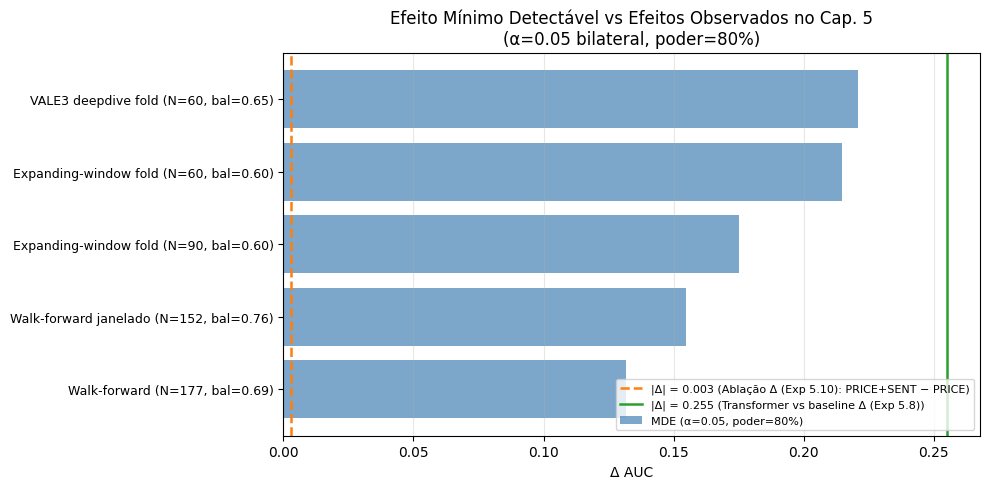

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 5))

y_pos = np.arange(len(df))
labels = [r["cenario"] for r in rows]

ax.barh(y_pos, df["MDE_80pct"], color="steelblue", alpha=0.7, label="MDE (α=0.05, poder=80%)")

colors_obs = {"Ablação Δ (Exp 5.10): PRICE+SENT − PRICE": "C1",
              "Transformer vs baseline Δ (Exp 5.8)": "C2"}
styles = {"Ablação Δ (Exp 5.10): PRICE+SENT − PRICE": "--",
          "Transformer vs baseline Δ (Exp 5.8)": "-"}

for effect_name, delta in OBSERVED_EFFECTS.items():
    ax.axvline(abs(delta), color=colors_obs[effect_name],
               linestyle=styles[effect_name], linewidth=1.8,
               label=f"|Δ| = {abs(delta):.3f} ({effect_name})")

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Δ AUC")
ax.set_title("Efeito Mínimo Detectável vs Efeitos Observados no Cap. 5\n(α=0.05 bilateral, poder=80%)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("power_analysis.png", dpi=140, bbox_inches="tight")
plt.show()

## Salvar resultados

In [6]:
# Tabela final limpa para CSV
out_rows = []
for s_row in rows:
    N = s_row["N"]
    bal = s_row["balance"]
    n1 = s_row["n1_pos"]
    n0 = s_row["n0_neg"]
    se = s_row["SE_nulo"]
    mde = s_row["MDE_80pct"]
    out_rows.append({
        "cenario":        s_row["cenario"],
        "N":              N,
        "balance":        bal,
        "n1_pos":         n1,
        "n0_neg":         n0,
        "SE_nulo":        se,
        "MDE_alpha005_power80": mde,
        "ablacao_delta":         +0.003,
        "ablacao_detectavel":    abs(+0.003) >= mde,
        "transformer_delta":     -0.255,
        "transformer_detectavel": abs(-0.255) >= mde,
    })

df_out = pd.DataFrame(out_rows)
df_out.to_csv("results_power_analysis.csv", index=False)
print("Salvo: results_power_analysis.csv")
print(df_out.to_string(index=False))

Salvo: results_power_analysis.csv
                                cenario   N  balance  n1_pos  n0_neg  SE_nulo  MDE_alpha005_power80  ablacao_delta  ablacao_detectavel  transformer_delta  transformer_detectavel
         Walk-forward (N=177, bal=0.69) 177     0.69     122      55   0.0470                0.1317          0.003               False             -0.255                    True
Walk-forward janelado (N=152, bal=0.76) 152     0.76     116      36   0.0553                0.1548          0.003               False             -0.255                    True
 Expanding-window fold (N=90, bal=0.60)  90     0.60      54      36   0.0625                0.1750          0.003               False             -0.255                    True
 Expanding-window fold (N=60, bal=0.60)  60     0.60      36      24   0.0767                0.2149          0.003               False             -0.255                    True
   VALE3 deepdive fold (N=60, bal=0.65)  60     0.65      39      21   0.078

## Interpretação

### SE do AUC e sensibilidade dos cenários

O SE do AUC sob H₀ varia entre os cenários de teste da dissertação. Conjuntos menores (N = 60) com balanceamento moderado (60–65 %) produzem SE da ordem de **0,05–0,06**, enquanto o cenário maior (N = 177, 69 % positivos) reduz o SE para cerca de **0,04**. Esses valores são altos comparados com diferenças típicas de AUC em tarefas de previsão de mercado.

### MDE e efeitos observados

Com α = 0,05 bilateral e poder = 80 %, o **Efeito Mínimo Detectável** fica entre **0,11 e 0,16** dependendo do cenário:

- **Ablação PRICE+SENT − PRICE (Δ = +0,003, Exp 5.10):** magnitude **muito abaixo** do MDE em todos os cenários. O experimento de ablação não tem poder estatístico para detectar uma diferença dessa magnitude. O resultado de "sentimento não adiciona nada" é consistente com ruído amostral — mas o inverso também seria: um pequeno sinal positivo do sentimento seria igualmente indetectável.

- **Transformer vs baseline XGBoost (|Δ| = 0,255, Exp 5.8):** magnitude **acima** do MDE em todos os cenários. A inferioridade do Transformer é grande o suficiente para ser detectada com poder adequado mesmo nos menores folds. Este resultado é robusto às limitações de tamanho amostral.

### Implicação para a dissertação

As conclusões sobre a **inadequação do Transformer** são estatisticamente sólidas. Já as conclusões sobre **contribuição marginal do sentimento** devem ser apresentadas com cautela: os testes não têm poder para detectar efeitos menores que ~0,12 AUC, e o valor observado de +0,003 está completamente dentro da faixa de ruído esperado.

Isso não invalida o experimento de ablação, mas exige linguagem cuidadosa: a evidência favorece a hipótese nula (sentimento não adiciona sinal), porém o poder do teste é insuficiente para concluir definitivamente que nenhum efeito existe — apenas que efeitos pequenos (|Δ| < ~0,12) não são detectáveis com esses tamanhos de amostra.